# ISW Reports Exploratory Data Analysis

This notebook transforms raw ISW (Institute for the Study of War) daily reports
into a structured numerical feature dataset for air alert prediction in Ukraine.

## Data Source
Daily ISW conflict assessment reports from February 24, 2022 to present,
scraped as raw HTML text and stored as a CSV file. Fields:
- `date`
- `url`
- `full_text`
- `word_count`


## Pipeline Overview

**Section 2: Data Overview**
Explored the raw dataset: confirmation no missed record values, identifies skipped dates, detecting dublicates and anomalies.

**Section 3: Preprocessing & Cleaning**
Removing outliners, processing missed dates, detecting time slots, exploaring text formating, applying NLP methods and preparing text data.


**Section 4: Feature Engineering**
- Building a TF-IDF bigram matrix, applying keyword-based threat category extraction across 9 military threat types using a two-stage refinement process: initial keyword vocabulary, followed by corpus diagnostics to identify weak categories, and expanded bigram lists verified against actual corpus content.
- Adding binary geographic coverage features for 23 Ukrainian regions and a
daily unique location count.
- Creating lag-1, lag-3, and 7-day rolling mean
features for all threat categories to capture temporal dynamics.

## Output
`isw_features_data.csv` — 1,469 rows × 62 columns, one row per day,
no missing values. Ready for merge with weather and air alert datasets
prior to model training.

# 1. Workspace Setup & Initialization

First, we connect Google Drive to the Colab environment and import the required libraries for our analysis.



## 1.1 Importing all the necessary libraries for data processing.


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math
import plotly.express as px
import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords
import math
from sklearn.feature_extraction.text import TfidfVectorizer

## 1.2 Connecting to Google Drive and loading the ISW reports data.

In [ ]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
csv_file = '/content/PATH_TO_FILE/isw_reports.csv'
df = pd.read_csv(csv_file)

# 2. Data overview

In this section, we will conduct a basic exploration of the dataset for further work with the data.

## 2.1 Previewing the top of the dataset to understand its structure.

In [ ]:
df.head()

,date,url,full_text,word_count
0,2022-02-24,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...,1593
1,2022-02-25,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...,1954
2,2022-02-26,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...,2642
3,2022-02-27,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...,2530
4,2022-02-27,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...,2581


We can see 4 columns:
- `date`: date of the report
- `url`: link to the report
- `full_text`: all text from the html for one report
- `word_count`: the count of words each report contains

## 2.2 Providing statistical overview

### 2.2.1 Basic metrics

In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        1458 non-null   object
 1   url         1458 non-null   object
 2   full_text   1458 non-null   object
 3   word_count  1458 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 167.9 MB


We can see no empty raws, the data type is:
- object for `date`: will need a change to datetime type
- object for `url` and full_text: as expected for the text data
- `word_count`: int64 as expected

### 2.2.2 Checking time period

Noting the first and the last records in the dataset to check the amount of rows.

In [ ]:
start_date = df['date'].min()
end_date = df['date'].max()

print(f"time period: {start_date} - {end_date}")

time period: 2022-02-24 - 2026-03-03


The dataset is complete with 1458 entries and no missing values. Also we used this command to verify data types: word_count  enables immediate numerical analysis, while date, url, and full_text are classified as objects. However, after performing calculations, we concluded that the dataset should contain 1469 entries. Therefore, we will now identify and display the missing dates.

### 2.2.3 Displaying missing dates

In [ ]:
df['date'] = pd.to_datetime(df['date'])

full_date_range = pd.date_range(start=start_date, end=end_date)
missing_dates = full_date_range.difference(df['date'])

print(f"Missing dates found: {len(missing_dates)}")
print("List of missing dates:")
missing_dates_list = [d.strftime('%Y-%m-%d') for d in missing_dates]
for d in missing_dates_list:
    print(d)

Missing dates found: 15
List of missing dates:
2022-11-24
2022-12-25
2023-01-01
2023-03-19
2023-07-08
2023-11-23
2023-12-25
2024-01-01
2024-10-08
2024-11-28
2024-12-25
2025-01-01
2025-11-27
2025-12-25
2026-01-01


After manual verification, we confirmed that most gaps in the dataset align with US holidays, while records for the other three days are simply missing from the official source.
If there are 15 missing dates, the dataset should be 1454, but we have 1458 - it still doesn't add up. Checking for duplicates in the dataset.

### 2.2.4 Displaying amount of duplicates

In [ ]:
df.apply(lambda x: x.duplicated().sum())

,0
date,4
url,0
full_text,0
word_count,190


No matches were found by URL and text - therefore, there are no duplicates. However, 4 duplicates were detected among the dates. Let's display them:

### 2.2.5 Displaying duplicates

In [ ]:
df[df.duplicated(subset=['date'], keep=False)].sort_values(by='date')

,date,url,full_text,word_count
3,2022-02-27,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...,2530
4,2022-02-27,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...,2581
964,2024-10-23,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,6275
965,2024-10-23,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,6273
1082,2025-02-20,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,158387
1083,2025-02-20,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,4551
1111,2025-03-20,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,6483
1112,2025-03-20,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,3950


We detected 4 dates with two reports. Since these are reports for the same day, we decided to merge the text into a single record. The merging is performed in the next section.

### 2.2.6 Providing a statistical overview of the word_count column.

In [ ]:
df.describe()

,date,word_count
count,1458,1458.000000
mean,2024-02-27 12:11:51.111110912,4584.124829
min,2022-02-24 00:00:00,979.000000
25%,2023-02-25 06:00:00,3686.000000
50%,2024-02-29 12:00:00,4531.000000
75%,2025-03-01 18:00:00,5404.500000
max,2026-03-03 00:00:00,158387.000000
std,NaN,4257.539066


We can see the average amount of words is `4584`, however the minimum record is `979` and the maximum is `158357`. The gap in values is quite huge. To understand the nature of such gap we will display the visualization of the word count distribution.

2.2.6.1 Visualizing word counts in reports over time to detect anomalies.

In [ ]:
df.sort_values(by='word_count', ascending=False).head(5)

,date,url,full_text,word_count
1082,2025-02-20,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,158387
1391,2025-12-26,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,9638
898,2024-08-17,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,8822
1161,2025-05-08,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,8280
827,2024-06-07,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,8222


In [ ]:
df.sort_values(by='word_count', ascending=True).head(5)

,date,url,full_text,word_count
284,2022-12-05,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,979
49,2022-04-13,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,1041
51,2022-04-15,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,1061
68,2022-05-02,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,1133
48,2022-04-12,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,1198


Displaying the top word counts we can see that only one value is extremely huge, whereas top minimum values are similar.

In [ ]:
min_word_count = df['word_count'].min()
max_word_count = 9638

The visualization shows that the range of word counts is between 979 and 9638, but one value is too big. It is a spike.

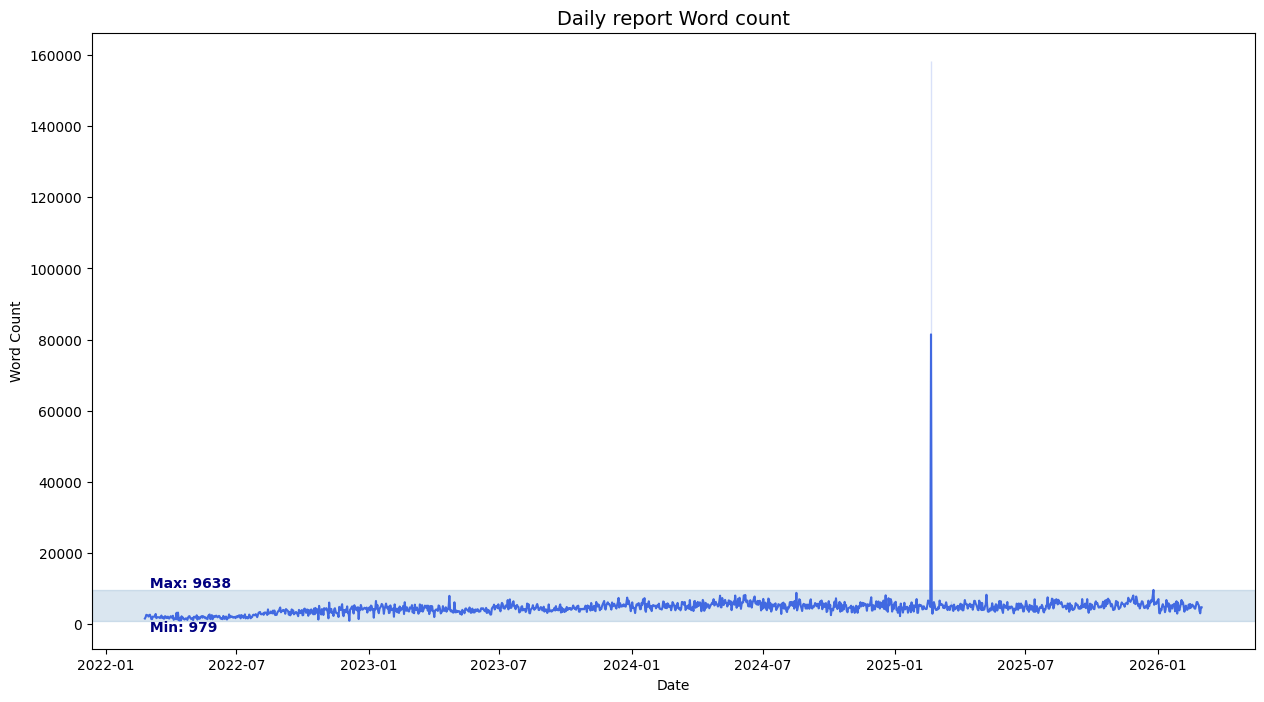

In [ ]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=df, x='date', y='word_count', color='royalblue')

plt.axhspan(ymin=min_word_count, ymax=max_word_count, color='steelblue', alpha=0.2)

x_pos = df['date'].min()

plt.text(x=x_pos, y=max_word_count, s=f' Max: {max_word_count}', color='navy', va='bottom', fontweight='bold')
plt.text(x=x_pos, y=min_word_count, s=f' Min: {min_word_count}', color='navy', va='top', fontweight='bold')

plt.title('Daily report Word count', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Word Count')
plt.show()

Upon inspecting the plot, we identified an outlier and proceeded to locate the record responsible for it.

In [ ]:
df[df['word_count'] > 9638]

,date,url,full_text,word_count
1082,2025-02-20,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...,158387


After following the link, we discovered that this was a consolidated report covering several months. Consequently, we have determined that this is not a duplicate based on the date, and the record will be excluded during the data cleaning stage.



#3. Data Preprocessing & Cleaning

In this section, we transition from raw data exploration to systematic data preparation. The primary goal is to refine the dataset and ensure it meets the requirements of our analytical models.

At firs we are creating the copy of dataset `df_cleaned` in order not to destroy our raw data.

In [ ]:
df_cleaned = df.copy()

##3.1 Cleaning data

### 3.1.1 Dropping the previously mentioned row with the report spanning several months.

In [ ]:
df_cleaned = df_cleaned.drop(index=1082)

### 3.1.2 Dropping url columns

We only needed url columns to verify the absence of duplicates. Our next step is to merge texts of days having more then one report a day, so there is no need to collect url anymore. If we have some problems while cleaning and will need a manual check of the html, we can search it by it's date or find the link using the raw dataset.

In [ ]:
df_cleaned = df_cleaned.drop(columns=['url'])

### 3.1.3 Aggregating the records by date

In [ ]:
df_cleaned = df_cleaned.groupby('date').agg(
    full_text=('full_text', lambda x: ' '.join(x.astype(str))),
    total_words=('word_count', 'sum')
).reset_index()

Here we merged texts with the same date, because it only matters the day of publication.

In [ ]:
df_cleaned.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1454 entries, 0 to 1453
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1454 non-null   datetime64[ns]
 1   full_text    1454 non-null   object        
 2   total_words  1454 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 164.3 MB


By displaying this overview we can see that the number of columns is exatly as we expected: 1454 rows in cleaned dataset + 15 non-existent reports = 1469 that accurately fits the time range.

###3.1.4 Creating new feature before reducing the beggining of the report

This step needs to be performed here, even though it might seem out of sequence. Each report begins with a standardized header, for example:

> Previous Next Russian Offensive Campaign Assessment, October 23, 2024 Christina Harward, Kateryna Stepanenko, Karolina Hird, Nicole Wolkov, Nate Trotter, William Runkel, Katherine Wells, and Frederick W. Kagan October 23, 2024, 7:45pm ET

While this header contains no relevant analytical information and is usually dropped, it ends with a timestamp. We decided to engineer a new feature from this: whether the report was published in the morning or the evening. Since the upcoming text cleaning step will remove digits and punctuation, extracting and categorizing this timestamp must be done before any text preprocessing.


3.1.4.1 Search for the timestamp

In [ ]:
def get_time_of_day(text):
    # search for the pattern of the timestamp
    match = re.search(r'(\d{1,2})(?::\d{2})?\s*(am|pm)\s*E[DS]?T', str(text), re.IGNORECASE)

    if match:
        hour = int(match.group(1))
        period = match.group(2).lower()
        if period == 'pm' and hour != 12:
            hour += 12
        elif period == 'am' and hour == 12:
            hour = 0

        return 1 if hour >= 18 else 0  # 1 = evening time of publication (>= 18:00), 0 = morning/day

    return None

In [ ]:
df_cleaned['is_evening_report'] = df_cleaned['full_text'].apply(get_time_of_day)

3.1.4.2 Vizualing the disrtibution

/tmp/ipykernel_418/3156046052.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=time_percentages.values, palette=['navy', 'blue', 'orange'])


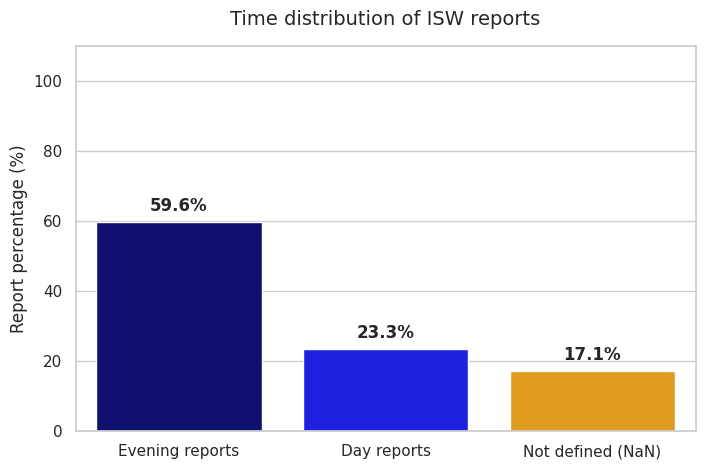

In [ ]:
# category percentage
time_counts = df_cleaned['is_evening_report'].value_counts(dropna=False)
time_percentages = (time_counts / time_counts.sum()) * 100

labels_map = {
    1.0: 'Evening reports',
    0.0: 'Day reports'
}
labels = [labels_map.get(x, 'Not defined (NaN)') for x in time_counts.index]

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x=labels, y=time_percentages.values, palette=['navy', 'blue', 'orange'])

# percentage
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')


plt.title('Time distribution of ISW reports', fontsize=14, pad=15)
plt.ylabel('Report percentage (%)', fontsize=12)
plt.ylim(0, 110)

plt.show()

We observe a hyge amount of not defined options that means the script of detecting the time patterns was inaccurate. Displaying NaN values to check:

3.1.4.3 Defining the timestamp problem

In [ ]:
nan_reports = df_cleaned[df_cleaned['is_evening_report'].isna()]

print(f"Total NaN records: {len(nan_reports)}\n")

for idx, text in enumerate(nan_reports['full_text'].head(10)):
    print(f"--- Not defined record {idx + 1} ---")
    print(str(text)[:300])
    print("\n")

Total NaN records: 248

--- Not defined record 1 ---
Previous
Next
Russian Offensive Campaign Assessment, March 18
Ukrainian forces conducted a major successful counterattack around Mykolayiv in the past several days, and Russian forces continued to secure territorial gains only around Mariupol on March 18.
Russian forces face growing morale and suppl


--- Not defined record 2 ---
Previous
Next
Russian Offensive Campaign Assessment, March 20, 2022
Russian forces did not make any major advances on March 20.
Russian forces around Kyiv are increasingly establishing defensive positions and preparing to deploy further artillery and fire control assets. Ukrainian forces repelled co


--- Not defined record 3 ---
Previous
Next
Russian Offensive Campaign Assessment, March 29
Frederick W. Kagan, George Barros, and Kateryna Stepanenko
March 29, 5:00 ET
The Russians have not yet abandoned their attacks on Kyiv, claims by Russian Defense Ministry officials notwithstanding. Russian forces continue

The problem is that am/pm marker is missed. We visualized the time distribution of the records to understand how to fix this missing:

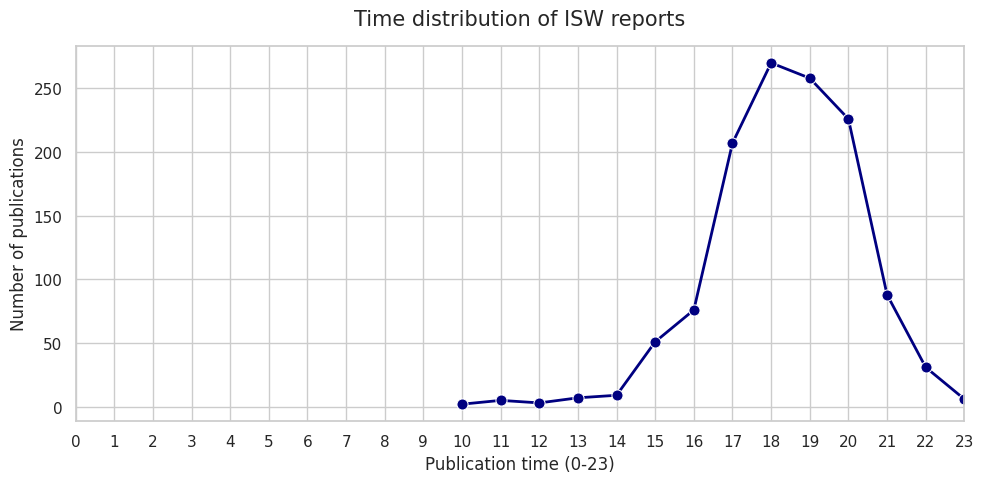

In [ ]:
def extract_exact_hour(text):
    match = re.search(r'(\d{1,2})(?::\d{2})?\s*(am|pm)?\s*E[DS]?T', str(text), re.IGNORECASE)
    if match:
        hour = int(match.group(1))

        # ignore time > 12
        if hour > 12:
            return None

        period = match.group(2).lower() if match.group(2) else 'pm'

        if period == 'pm' and hour != 12:
            hour += 12
        elif period == 'am' and hour == 12:
            hour = 0
        return hour
    return None


df_cleaned['pub_hour_et'] = df_cleaned['full_text'].apply(extract_exact_hour)
hourly_counts = df_cleaned['pub_hour_et'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    x=hourly_counts.index,
    y=hourly_counts.values,
    marker='o',
    markersize=8,
    color='navy',
    linewidth=2
)

plt.title('Time distribution of ISW reports', fontsize=15, pad=15)
plt.xlabel('Publication time (0-23)', fontsize=12)
plt.ylabel('Number of publications', fontsize=12)


plt.xlim(0, 23)
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

Since the vast majority of reports are published after 12, for all missing values of am/pm ​​we will apply pm.

3.1.4.4 Fixed code and visualization:

In [ ]:
def get_time_of_day(text):
  # add pm if the value is missing
    match = re.search(r'(\d{1,2})(?::\d{2})?\s*(am|pm)?\s*E[DS]?T', str(text), re.IGNORECASE)

    if match:
        hour = int(match.group(1))
        period = match.group(2).lower() if match.group(2) else 'pm'


        if period == 'pm' and hour != 12:
            hour += 12
        elif period == 'am' and hour == 12:
            hour = 0

        return 1 if hour >= 18 else 0

    return None

df_cleaned['is_evening_report'] = df_cleaned['full_text'].apply(get_time_of_day)

/tmp/ipykernel_418/2853190889.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=time_percentages.values, palette=['navy', 'blue', 'orange'])


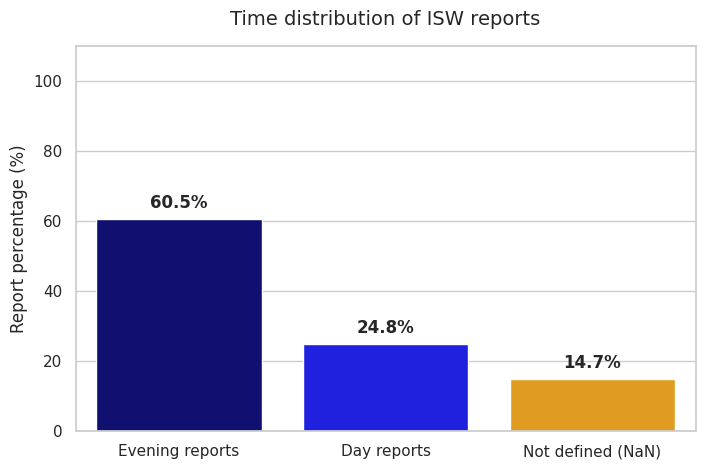

In [ ]:
time_counts = df_cleaned['is_evening_report'].value_counts(dropna=False)
time_percentages = (time_counts / time_counts.sum()) * 100

labels_map = {
    1.0: 'Evening reports',
    0.0: 'Day reports'
}
labels = [labels_map.get(x, 'Not defined (NaN)') for x in time_counts.index]

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x=labels, y=time_percentages.values, palette=['navy', 'blue', 'orange'])


for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')


plt.title('Time distribution of ISW reports', fontsize=14, pad=15)
plt.ylabel('Report percentage (%)', fontsize=12)
plt.ylim(0, 110)

plt.show()

In [ ]:
nan_reports = df_cleaned[df_cleaned['is_evening_report'].isna()]

print(f"NaN records: {len(nan_reports)}\n")

for idx, text in enumerate(nan_reports['full_text'].head(5)):
    print(f"--- Not defined record {idx + 1} ---")
    print(str(text)[:300])
    print("\n")

NaN records: 214

--- Not defined record 1 ---
Previous
Next
Russian Offensive Campaign Assessment, March 18
Ukrainian forces conducted a major successful counterattack around Mykolayiv in the past several days, and Russian forces continued to secure territorial gains only around Mariupol on March 18.
Russian forces face growing morale and suppl


--- Not defined record 2 ---
Previous
Next
Russian Offensive Campaign Assessment, March 20, 2022
Russian forces did not make any major advances on March 20.
Russian forces around Kyiv are increasingly establishing defensive positions and preparing to deploy further artillery and fire control assets. Ukrainian forces repelled co


--- Not defined record 3 ---
Previous
Next
Russian Offensive Campaign Assessment, April 9, 2023
Click
here
to see ISW’s interactive map of the Russian invasion of Ukraine. This map is updated daily alongside the static maps present in this report.
Click
here
to access ISW’s archive of interactive time-lapse maps of t

This way we were able to correct the error in 34 records, but still left 214 undefined. Machine learning models cannot work with missing data, so they had to be replaced. Since the vast majority of ISW reports are traditionally published in the evening, filling these gaps with the value 1 (evening report) is the most statistically sound solution.

In [ ]:
df_cleaned['is_evening_report'] = df_cleaned['is_evening_report'].fillna(1.0)

/tmp/ipykernel_418/1775004541.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=time_percentages.values, palette=['navy', 'blue', 'orange'])
/tmp/ipykernel_418/1775004541.py:13: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.barplot(x=labels, y=time_percentages.values, palette=['navy', 'blue', 'orange'])


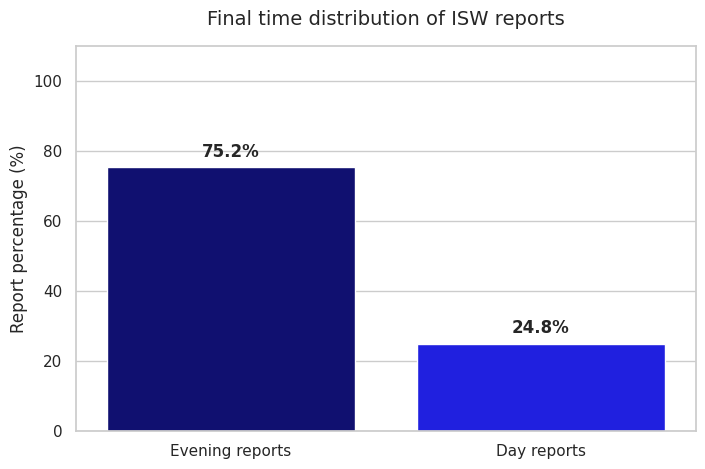

In [ ]:
time_counts = df_cleaned['is_evening_report'].value_counts(dropna=False)
time_percentages = (time_counts / time_counts.sum()) * 100

labels_map = {
    1.0: 'Evening reports',
    0.0: 'Day reports'
}
labels = [labels_map.get(x, 'Not defined (NaN)') for x in time_counts.index]

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x=labels, y=time_percentages.values, palette=['navy', 'blue', 'orange'])


for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')


plt.title('Final time distribution of ISW reports', fontsize=14, pad=15)
plt.ylabel('Report percentage (%)', fontsize=12)
plt.ylim(0, 110)

plt.show()

The time of the report's release affects the forecast\. The evening report, Washington time, appears late at night in Kyiv, covering the events of the previous day. This binary marker allows us to correctly weigh the "freshness" of the context when forecasting air alerts for the next day.

In [ ]:
df_cleaned.drop(columns=['pub_hour_et'], inplace=True)

In [ ]:
df_cleaned['is_evening_report'] = df_cleaned['is_evening_report'].astype(int)

In [ ]:
df_cleaned.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1454 entries, 0 to 1453
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               1454 non-null   datetime64[ns]
 1   full_text          1454 non-null   object        
 2   total_words        1454 non-null   int64         
 3   is_evening_report  1454 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 164.3 MB


### 3.1.5 Selecting timestamps

Since we will be working with temporal data, it would be more informative to store a temporal slice of the report data and fill the range between reports with this information. To do this, we use the following code:

In [ ]:
def extract_exact_time(text):
    match = re.search(r'(\d{1,2})(?::(\d{2}))?\s*(am|pm)?\s*E[DS]?T', str(text), re.IGNORECASE)

    if match:
        hour = int(match.group(1))

        if hour > 12:
            return pd.NA

        minute = int(match.group(2)) if match.group(2) else 0
        period = match.group(3).lower() if match.group(3) else 'pm'

        if period == 'pm' and hour != 12:
            hour += 12
        elif period == 'am' and hour == 12:
            hour = 0

        return f"{hour:02d}:{minute:02d}"

    return pd.NA

In [ ]:
df_cleaned['pub_time_et'] = df_cleaned['full_text'].apply(extract_exact_time)

# detecting missed data
total_rows = len(df_cleaned)
normal_count = df_cleaned['pub_time_et'].notna().sum()
missing_count = df_cleaned['pub_time_et'].isna().sum()

print("Time extraction overview")
print(f"Count of reports: {total_rows}")
print(f"Time detected: {normal_count} ({(normal_count/total_rows)*100:.1f}%)")
print(f"Time missed: {missing_count} ({(missing_count/total_rows)*100:.1f}%)")

# filling missed data with the info about the previous day
df_cleaned['pub_time_et'] = df_cleaned['pub_time_et'].ffill().bfill()

# initializing datetime (поки що це "наївний" час)
df_cleaned['pub_datetime_raw'] = pd.to_datetime(df_cleaned['date'].astype(str) + ' ' + df_cleaned['pub_time_et'])

# create utc
df_cleaned['pub_datetime_tz'] = df_cleaned['pub_datetime_raw'].dt.tz_localize('America/New_York')

# convert to utc
df_cleaned['pub_datetime_utc'] = df_cleaned['pub_datetime_tz'].dt.tz_convert('UTC')

# rounding up
df_cleaned['pub_datetime_rounded'] = df_cleaned['pub_datetime_utc'].dt.ceil('H').dt.tz_localize(None)


# datetime formating
df_cleaned['report_timestamp'] = df_cleaned['pub_datetime_rounded'].dt.strftime('%Y-%m-%d %H:%M:%S')

# delete extra columns (додали сюди нові проміжні колонки)
df_cleaned = df_cleaned.drop(columns=[
    'pub_time_et',
    'pub_datetime_raw',
    'pub_datetime_tz',
    'pub_datetime_utc',
    'pub_datetime_rounded'
])

print(df_cleaned[['date', 'report_timestamp']].head(10))

Time extraction overview
Count of reports: 1454
Time detected: 1239 (85.2%)
Time missed: 215 (14.8%)
        date     report_timestamp
0 2022-02-24  2022-02-24 20:00:00
1 2022-02-25  2022-02-25 20:00:00
2 2022-02-26  2022-02-26 20:00:00
3 2022-02-27  2022-02-27 21:00:00
4 2022-02-28  2022-02-28 21:00:00
5 2022-03-01  2022-03-01 20:00:00
6 2022-03-02  2022-03-02 22:00:00
7 2022-03-03  2022-03-03 21:00:00
8 2022-03-04  2022-03-04 20:00:00
9 2022-03-05  2022-03-05 20:00:00


/tmp/ipykernel_418/3424153128.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_cleaned['pub_datetime_rounded'] = df_cleaned['pub_datetime_utc'].dt.ceil('H').dt.tz_localize(None)


In [ ]:
df_cleaned.head()

,date,full_text,total_words,is_evening_report,report_timestamp
0,2022-02-24,Previous\nNext\nRussia-Ukraine Warning Update:...,1593,0,2022-02-24 20:00:00
1,2022-02-25,Previous\nNext\nRussia-Ukraine Warning Update:...,1954,0,2022-02-25 20:00:00
2,2022-02-26,Previous\nNext\nRussia-Ukraine Warning Update:...,2642,0,2022-02-26 20:00:00
3,2022-02-27,Previous\nNext\nRussia-Ukraine Warning Update:...,5111,0,2022-02-27 21:00:00
4,2022-02-28,Previous\nNext\nRussian Offensive Campaign Ass...,2489,0,2022-02-28 21:00:00


In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1454 entries, 0 to 1453
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               1454 non-null   datetime64[ns]
 1   full_text          1454 non-null   object        
 2   total_words        1454 non-null   int64         
 3   is_evening_report  1454 non-null   int64         
 4   report_timestamp   1454 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 56.9+ KB


## 3.2 NLP

In this part we provide the preparation of our main source of data: texts of the reports. By checking it manually we noticed that despite basic cleaning we will need to reduce some information that was scrapped from the html, but not being the part of report:
- navigation links, as part of html: `/nPrevious /nNext`
- the repetitive name of the report
- authors of the report
- links in the end

Description of the cleaning is provided in the code as comments.

We are to use `library re` for easy text operating.

### 3.2.1 Text cleaning and tokenization

Initially, we assumed that the standard technical "cap" of each ISW report always ends with a timestamp (e.g. 7:30 pm ET). However, the analysis showed that in some publications there is no time, and the title ends simply with a year or date (e.g. March 20, 2022).

To correctly clean absolutely all texts from irrelevant introductions, we adapted the algorithm. Now it flexibly cuts off the cap, checking the conditions in priority: first it looks for a timestamp, and if it is not there, it focuses on the year of publication. Everything up to the found point is automatically deleted.

3.2.1.1 Cleaning the beginning

In [ ]:
def clean_isw_header(text):
    text = str(text)

    # working with first symbols to avoid miscleaning
    header_zone = text[:500]

    # variant 1: cap ends with a timestamp (eg "7:30 ET")
    match_time = re.search(r'(?i)(?:am|pm)?\s*E[DS]?T\s*\n', header_zone)
    if match_time:
        return text[match_time.end():].strip()

    # variant 2: cap ends with a year (eg "March 20, 2022")
    match_year = re.search(r'\b(202[2-9])\s*\n', header_zone)
    if match_year:
        return text[match_year.end():].strip()

    # variant 3: cap ends with a date (eg "March 18")
    months = r'(?:January|February|March|April|May|June|July|August|September|October|November|December)'
    match_date = re.search(rf'{months}\s+\d{{1,2}}\s*\n', header_zone, re.IGNORECASE)
    if match_date:
        return text[match_date.end():].strip()

    text = re.sub(r'(?i)Previous\s*Next\s*', ' ', text)
    text = re.sub(r'(?i)Russian Offensive Campaign Assessment[^\n]*\n', ' ', text)

    # no specific match
    return text.strip()

df_cleaned['cleaned_text'] = df_cleaned['full_text'].apply(clean_isw_header)

3.2.1.2 Basic text formating

In [ ]:
def clean_isw_text(text):
    # reduce links in the end
    text = text.split('Endnotes')[0]

    # reduce urls
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # clean digits
    text = re.sub(r'\b\w*\d\w*\b', '', text)

    # cleaning, keep letters only
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    text = text.lower()

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_cleaned['cleaned_text'] = df_cleaned['cleaned_text'].apply(clean_isw_text)

### 3.2.2 Removing stopwords

In [ ]:
# using library with the set of stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    filtered = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered)

df_cleaned['cleaned_text'] = df_cleaned['cleaned_text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Checking data:

In [ ]:
df_cleaned.head()


,date,full_text,total_words,is_evening_report,report_timestamp,cleaned_text
0,2022-02-24,Previous\nNext\nRussia-Ukraine Warning Update:...,1593,0,2022-02-24 20:00:00,russian president vladimir putin began large s...
1,2022-02-25,Previous\nNext\nRussia-Ukraine Warning Update:...,1954,0,2022-02-25 20:00:00,russian forces entered major ukrainian cities ...
2,2022-02-26,Previous\nNext\nRussia-Ukraine Warning Update:...,2642,0,2022-02-26 20:00:00,russian forces main axes advance last hours fo...
3,2022-02-27,Previous\nNext\nRussia-Ukraine Warning Update:...,5111,0,2022-02-27 21:00:00,russian military likely recognized initial exp...
4,2022-02-28,Previous\nNext\nRussian Offensive Campaign Ass...,2489,0,2022-02-28 21:00:00,russian military reorganizing military efforts...


### 3.2.3 Entering missed data

Before moving to the next steps, we need to include the 15 missing days we found in point 2, because our model will not be able to handle missing data. We will fill in the important data with nulls, so the model will simply consider them not influential.

In [ ]:
full_date_range = pd.date_range(start=start_date, end=end_date, freq='D')

df_cleaned = df_cleaned.set_index('date').reindex(full_date_range)

# filling the missing values (NaN) with the appropriate values:
df_cleaned['full_text'] = df_cleaned['full_text'].fillna('')
df_cleaned['cleaned_text'] = df_cleaned['cleaned_text'].fillna('')
df_cleaned['is_evening_report'] = df_cleaned['is_evening_report'].fillna(0).astype(int)
#specific filling for the timestamps
times = df_cleaned['report_timestamp'].str.split(' ').str[-1].ffill().bfill()
df_cleaned['report_timestamp'] = df_cleaned.index.strftime('%Y-%m-%d') + ' ' + times

if 'total_words' in df_cleaned.columns:
    df_cleaned['total_words'] = df_cleaned['total_words'].fillna(0).astype(int)

# reset the index to move the date back into a column and rename it to 'date'
df_cleaned = df_cleaned.reset_index().rename(columns={'index': 'date'})

In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469 entries, 0 to 1468
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               1469 non-null   datetime64[ns]
 1   full_text          1469 non-null   object        
 2   total_words        1469 non-null   int64         
 3   is_evening_report  1469 non-null   int64         
 4   report_timestamp   1469 non-null   object        
 5   cleaned_text       1469 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 69.0+ KB


At this stage, we transformed the raw texts of ISW reports into clean data. We left important information about the publication time and normalized the missing information, cleaned the texts from unnecessary information: standard headings, footnotes, navigation, irrelevant symbols and meaningless stop words. As a result, we were left with only the essence of the texts without any technical garbage, which will become the basis for the next step of creating bigrams, text processing and highlighting the main features.

# 4. Feature engineering

In this section, we transform the cleaned text into a structured numerical format. By using TF-IDF vectorization with a focus on bigrams, we aim to capture meaningful military and geopolitical contexts. We also implement statistical filtering to remove "structural noise"—repetitive phrases specific to the ISW reporting style—to ensure the model focuses on unique daily events.

## 4.1 TF-IDF vectorization

### 4.1.1 Creating a TF-IDF matrix

This code configures a TF-IDF vectorizer to extract bigrams while filtering out both rare and overly common phrases.

In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range=(2, 2),  # extract only bigrams
    min_df=5,            # ignore very rare bigrams (must appear in at least 5 documents)
    max_df=0.98          # ignore extremely common bigrams (present in more than 98% of documents)
)

In [ ]:
X = vectorizer.fit_transform(df_cleaned['cleaned_text'])
feature_names = vectorizer.get_feature_names_out()
scores = np.asarray(X.mean(axis=0)).ravel()

In [ ]:
print(f"Total bigrams in vocabulary: {X.shape[1]}")

Total bigrams in vocabulary: 70949


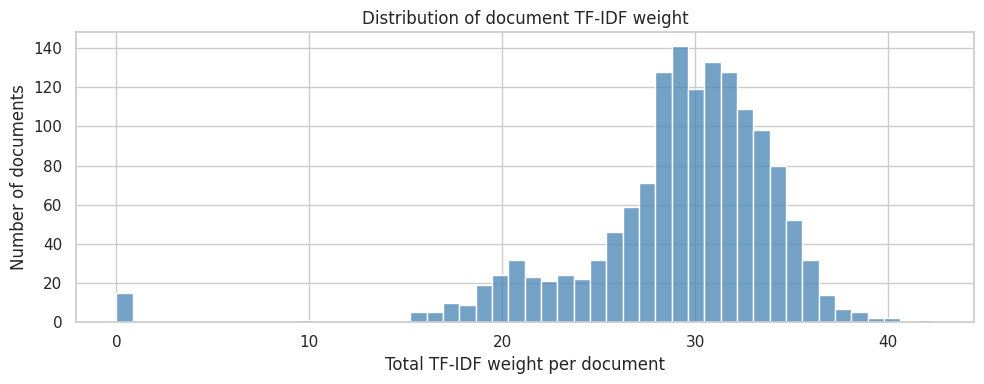

In [ ]:
doc_lengths = np.asarray(X.sum(axis=1)).ravel()
plt.figure(figsize=(10, 4))
sns.histplot(doc_lengths, bins=50, color='steelblue')
plt.title('Distribution of document TF-IDF weight')
plt.xlabel('Total TF-IDF weight per document')
plt.ylabel('Number of documents')
plt.tight_layout()
plt.show()

This histogram shows the distribution of total TF-IDF bigram weight per document. Most reports have a total weight between 20 and 40, which reflects typical daily ISW report length and content density. A small cluster of documents near zero corresponds to the 15 missing days filled with empty strings during preprocessing — these documents contain no text and therefore carry no TF-IDF signal. This is expected behaviour and confirms that the vectorization correctly reflects the actual information content of each report.

### 4.1.2 Exploring top-20 bigrams

The first analysis of the top 20 bigrams showed that the most popular were not substantive military events, but specific "structural noise" - template words that ISW authors use (`continued, claimed, reported, recently advanced, milblogger`).

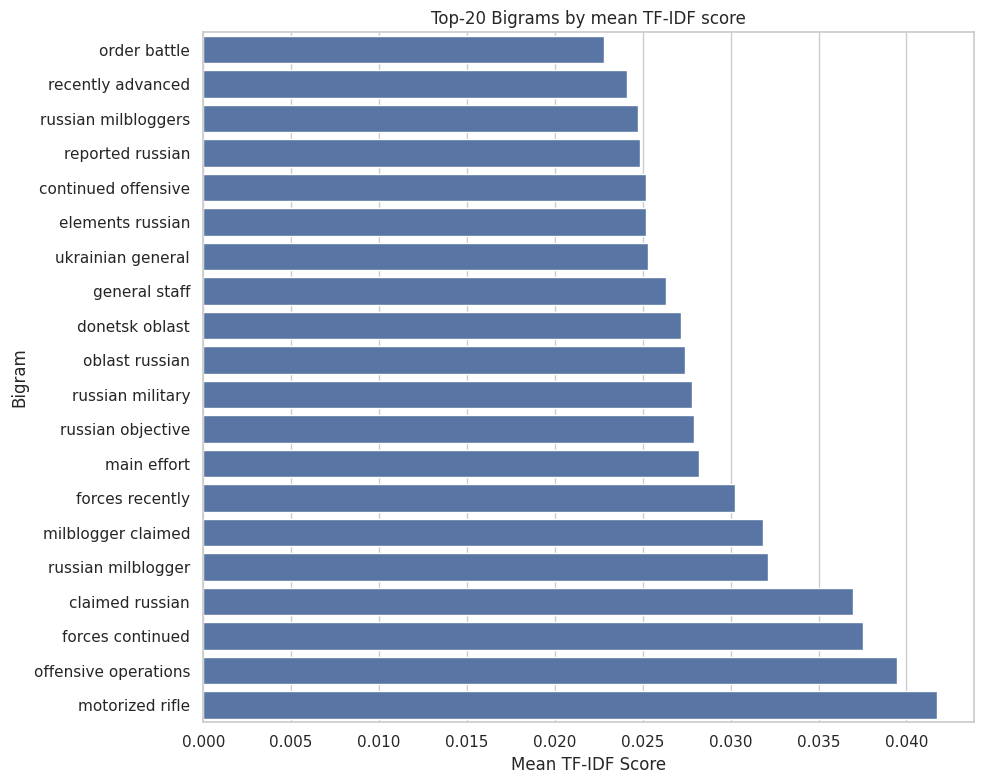

In [ ]:
top_indices = scores.argsort()[-20:]
bigrams_top = [feature_names[i] for i in top_indices]
tfidf_scores_top = [scores[i] for i in top_indices]

plt.figure(figsize=(10, 8))
sns.barplot(x=tfidf_scores_top, y=bigrams_top)
plt.title('Top-20 Bigrams by mean TF-IDF score')
plt.xlabel('Mean TF-IDF Score')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

Although limiting max_df to 98% helped discard very common terms (`russian forces, ukrainian military` present in almost every paragraph of any report), the data remains unrepresentative. Therefore, we move to category-based extraction.

### 4.1.3 Categorization

 We create a dictionary with keywords per threat category and hypothesize
that the texts contain bigrams with these keywords.

4.1.3.1 Initial keyword categories

In [ ]:
bigrams_df = pd.DataFrame({'bigram': feature_names, 'score': scores})

In [ ]:
# keyword categories

kw_dict1 = {
    'drones': ['shahed', 'drone', 'uav', 'kamikaze', 'loitering munition', 'iranian', 'chauda', 'primorsko', 'akhtarsk', 'yeysk'],
    'ballistic_missiles': ['ballistic', 'kinzhal', 'iskander', ' s ', ' kn ', 'belgorod', 'dzhankoi'],
    'cruise_missiles': ['cruise missile', 'kalibr', ' kh ', 'caspian'],
    'guided_bombs': ['glide', 'guided', ' kab ', 'fab', 'aasm'],
    'strategic_aviation': ['strategic aviation', ' tu ', 'bomber', 'takeoff', 'olenya', 'engels', 'mozdok', 'dyagilevo', 'airbase', 'airfield'],
    'naval_carriers': ['sea fleet', 'submarine', 'missle carrier', 'novorossiysk', 'sevastopol', 'naval base'],
    'massive_strike_context': ['massive strike', 'large scale strike', 'combined strike','waves', 'salvo','barrage'],
    'launch_activity': ['launch', 'takeoff', 'sortie', 'launch site', 'launch platform'],
    'air_defense_context': ['air defense', 'interception', 'shoot down', 'intercepted', 'patriot', ' s ',],
    'energy_targets': ['energy infrastructure','power plant','power grid', 'substation', 'electricity'],
    'military_targets': [ 'military infrastructure', 'command post', 'ammunition depot', 'logistics hub', 'training ground']
    }

In [ ]:
def build_category_tables(kw_dict, bigrams_df, top_n=20):
    #Match bigrams to categories and return dict of top-N tables per category
    matched_dfs = []
    for category, keywords in kw_dict.items():
        pattern = '|'.join([re.escape(k) for k in keywords])
        matched = bigrams_df[
            bigrams_df['bigram'].str.contains(pattern, case=False, na=False)
        ].copy()
        if not matched.empty:
            matched['category'] = category
            matched_dfs.append(matched)

    if not matched_dfs:
        return {}

    verified_df = pd.concat(matched_dfs, ignore_index=True)
    verified_df = verified_df.sort_values(by=['category', 'score'], ascending=[True, False])

    category_tables = {}
    for category in verified_df['category'].unique():
        category_tables[category] = (
            verified_df[verified_df['category'] == category]
            .sort_values('score', ascending=False)
            .head(top_n)
            [['bigram', 'score']]
            .reset_index(drop=True)
        )
    return category_tables

In [ ]:
def plot_heatmap(category_tables, df_tfidf, title, filename):
    # plot heatmap of threat category intensity over time
    df_tmp = df_tfidf.copy()
    df_tmp['month'] = pd.to_datetime(df_tmp['date']).dt.to_period('M')

    heatmap_data = {}
    for category, df_cat in category_tables.items():
        existing_cols = [
            b for b in df_cat['bigram'].tolist()
            if b in df_tmp.columns and b != ''
        ]
        if existing_cols:
            heatmap_data[category] = df_tmp.groupby('month')[existing_cols].mean().mean(axis=1)

    heatmap_df = pd.DataFrame(heatmap_data)

    plt.figure(figsize=(14, 8))
    sns.heatmap(
        heatmap_df.T,
        cmap='Blues',
        linewidths=0.5,
        cbar_kws={'label': 'Mean TF-IDF Score'}
    )
    plt.title(title, fontsize=14)
    plt.xlabel('Month')
    plt.ylabel('Threat Category')
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

**4.1.3.3 Heatmap of keyword categories**

shows whether categories change over time or are static

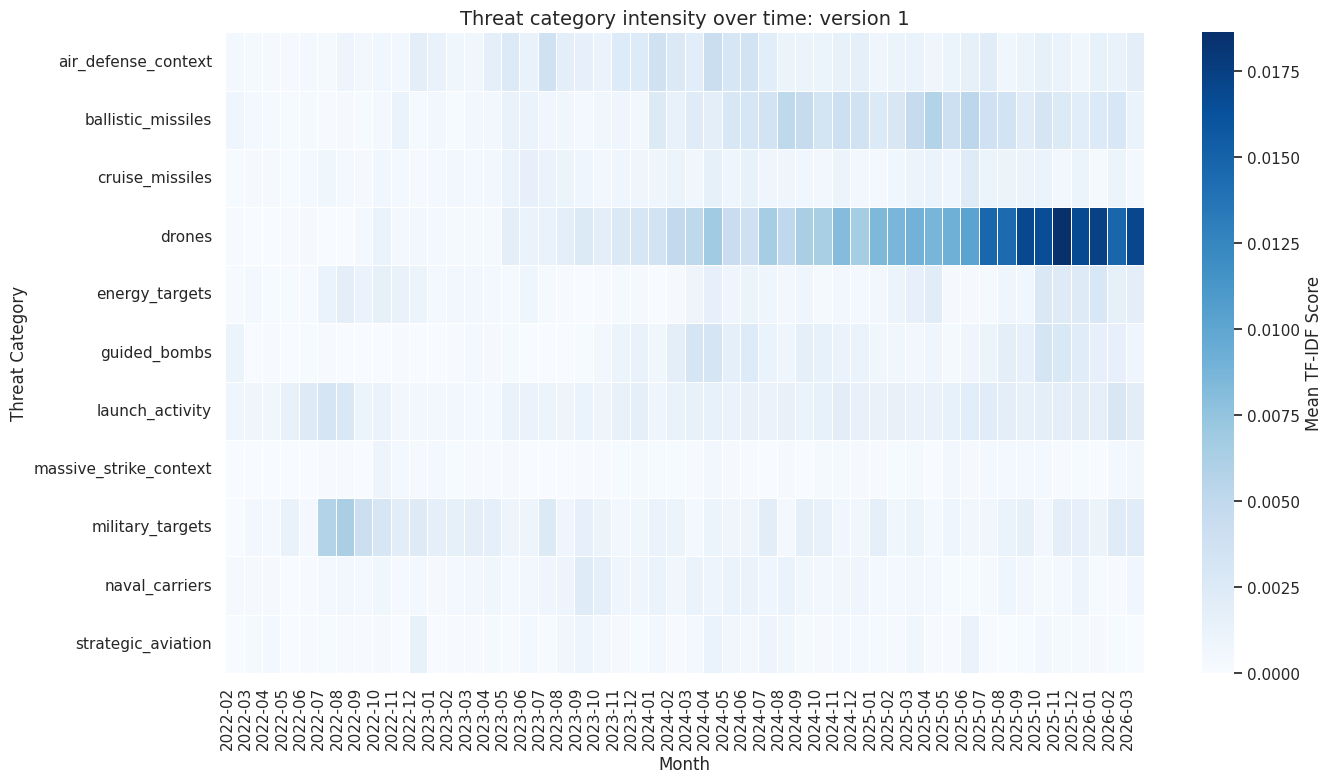

In [ ]:
category_tables_v1 = build_category_tables(kw_dict1, bigrams_df)

df_tfidf = pd.DataFrame(X.toarray(), columns=feature_names)
df_tfidf['date'] = df_cleaned.reset_index()['date']


plot_heatmap(
    category_tables_v1,
    df_tfidf,
    title='Threat category intensity over time: version 1',
    filename='isw_heatmap_v1.png',
)

Drones is the dominant category with a clear growth trend.
Starting from mid-2022, the intensity has been steadily increasing and reaches a peak in 2025-2026. This fully corresponds to reality - the massive use of Shahed began in September 2022 and increased every year.

Most of the categories are almost empty - `massive_strike_context, naval_carriers, strategic_aviation, cruise_missiles` are almost not captured. Let's expand the list of keywords and see if this will affect the effectiveness


**4.1.3.4 Expanding keyword categories**

The initial categorization revealed that several threat categories produced near-zero TF-IDF signals. Rather than discarding them immediately, we investigated whether the issue stemmed from keyword mismatch — specifically, whether our search terms were unigrams while the corpus only contained them as part of bigrams. To verify this, we queried the corpus directly for each weak category, retrieving the top-5 most frequent bigrams containing each search term.

In [ ]:
# check weak catwgories
weak_categories = {
    'cruise_missiles': ['kalibr', 'cruise', 'kh ', 'caspian', ' kh '],
    'massive_strike_context': ['massive', 'large scale', 'combined', 'wave', 'salvo', 'barrage', 'simultaneous'],
    'naval_carriers': ['black sea', 'fleet', 'submarine', 'naval', 'novorossiysk', 'sevastopol'],
    'strategic_aviation': ['strategic', 'bomber', ' tu ', 'engels', 'airfield', 'airbase'],
}

for category, search_terms in weak_categories.items():
    print(f"\n{'='*50}")
    print(f"CATEGORY: {category}")
    print(f"{'='*50}")
    for term in search_terms:
        found = [c for c in df_tfidf.columns if term.lower() in c.lower()]
        if found:
            # top-5  score
            scores_found = bigrams_df[bigrams_df['bigram'].isin(found)].sort_values('score', ascending=False).head(5)
            print(f"\n  '{term}' found {len(found)} bigrams:")
            print(scores_found[['bigram', 'score']].to_string(index=False))
        else:
            print(f"\n  '{term}' → no matches")


CATEGORY: cruise_missiles

  'kalibr' found 18 bigrams:
         bigram    score
  kalibr cruise 0.001551
kalibr missiles 0.000945
    four kalibr 0.000401
   three kalibr 0.000296
missiles kalibr 0.000291

  'cruise' found 28 bigrams:
         bigram    score
cruise missiles 0.005839
      kh cruise 0.003561
 cruise missile 0.002284
  kalibr cruise 0.001551
iskander cruise 0.001150

  'kh ' found 20 bigrams:
     bigram    score
  kh cruise 0.003561
kh missiles 0.001746
      kh kh 0.001328
 kh missile 0.001180
 kh kinzhal 0.000900

  'caspian' found 7 bigrams:
          bigram    score
caspian flotilla 0.001060
regiment caspian 0.000948
     caspian sea 0.000852
 bombers caspian 0.000163
  russia caspian 0.000133

  ' kh ' → no matches

CATEGORY: massive_strike_context

  'massive' found 15 bigrams:
           bigram    score
  massive missile 0.000404
  another massive 0.000354
  massive russian 0.000316
   massive series 0.000258
conducted massive 0.000247

  'large scale' found 1

To analyze weak categories, we assessed which bigrams had the lowest ratings. Using artificial intelligence, we asked to expand the keyword lists for the categories that gave the least information to capture more relevant bigrams.

In [ ]:
kw_dict2 = {
    'drones': [
        'shahed', 'drone', 'uav', 'kamikaze', 'loitering munition',
        'iranian', 'chauda', 'primorsko', 'akhtarsk', 'yeysk',
        'naval drone',
        'fpv drone',
    ],

    'ballistic_missiles': [
        'ballistic', 'kinzhal', 'iskander', 'belgorod', 'dzhankoi',
        'kh kinzhal',
    ],

    'cruise_missiles': [
        'cruise missiles',    # 0.005839
        'kh cruise',          # 0.003561
        'cruise missile',     # 0.002284
        'kalibr cruise',      # 0.001551
        'iskander cruise',    # 0.001150
        'kh missiles',        # 0.001746
        'kh missile',         # 0.001180
        'kalibr missiles',    # 0.000945
        'caspian flotilla',   # 0.001060
        'regiment caspian',   # 0.000948
    ],

    'guided_bombs': [
        'glide', 'guided', 'fab', 'aasm',
        'glide bombs',
        'guided bombs',
    ],

    'strategic_aviation': [
        'strategic bombers',  # 0.000921
        'tu bombers',         # 0.000519
        'strategic bomber',   # 0.000262
        'heavy bomber',       # 0.000300
        'engels airbase',     # 0.000535
        'engels air',         # 0.000403
        'airfield near',      # 0.000499
        'military airfield',  # 0.000537
        'belbek airfield',    # 0.000431
    ],

    'naval_carriers': [
        'black sea',          # 0.007664
        'naval infantry',     # 0.007871
        'russian naval',      # 0.004116
        'sea fleet',          # 0.004038
        'pacific fleet',      # 0.003802
        'northern fleet',     # 0.002098
        'ukrainian naval',    # 0.001471
        'naval drone',        # 0.001389
        'occupied sevastopol',# 0.001425
        'sevastopol crimea',  # 0.001052
        'novorossiysk krasnodar', # 0.000601
        'port novorossiysk',  # 0.000346
    ],

    'massive_strike_context': [
        'large scale',        # 0.005387
        'simultaneous offensive', # 0.000439
        'conduct simultaneous',   # 0.000280
        'massive missile',    # 0.000404
        'another massive',    # 0.000354
        'massive series',     # 0.000258
        'conducted massive',  # 0.000247
        'second wave',        # 0.001524
        'new wave',           # 0.000734
        'another wave',       # 0.000652
        'artillery barrages',
        'large attack',
        'scale attak'
    ],

    'launch_activity': [
        'launch', 'takeoff', 'sortie', 'launch site', 'launch platform'
    ],

    'air_defense_context': [
        'air defense', 'interception', 'shoot down', 'intercepted', 'patriot'
    ],

    'energy_targets': [
        'energy infrastructure', 'power plant', 'power grid',
        'substation', 'electricity'
    ],

    'military_targets': [
        'military infrastructure', 'command post', 'ammunition depot',
        'logistics hub', 'training ground'
    ],
}

**4.1.3.5 Noticing the difference in data categories**

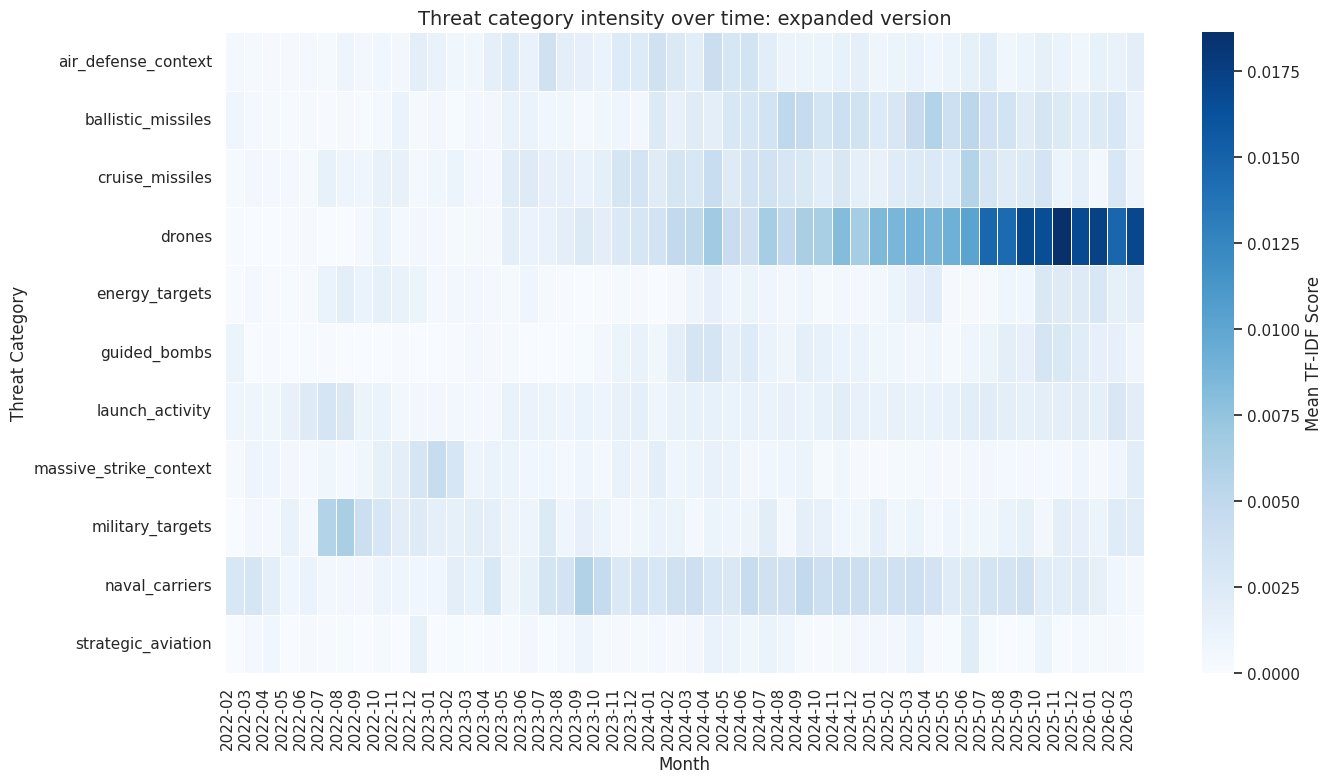

In [ ]:
category_tables_v2 = build_category_tables(kw_dict2, bigrams_df)

# 4.1.5.1 Heatmap v2 compare with v1 to confirm improvement
plot_heatmap(
    category_tables_v2,
    df_tfidf,
    title='Threat category intensity over time: expanded version',
    filename='isw_heatmap_v2.png'
)

We can clearly see that second selection gives more data, especially for the categories like: `military_targets, naval_carriers, cruise_missles`.  

In [ ]:
# Use v2 as the final category tables
category_tables = category_tables_v2

### 4.1.4 Validating categories

**4.1.4.1 Top-10 bigrams per category**

At this stage, we display top 10 bigrams by category to make sure that the bigrams really match the category and do not contain noise.

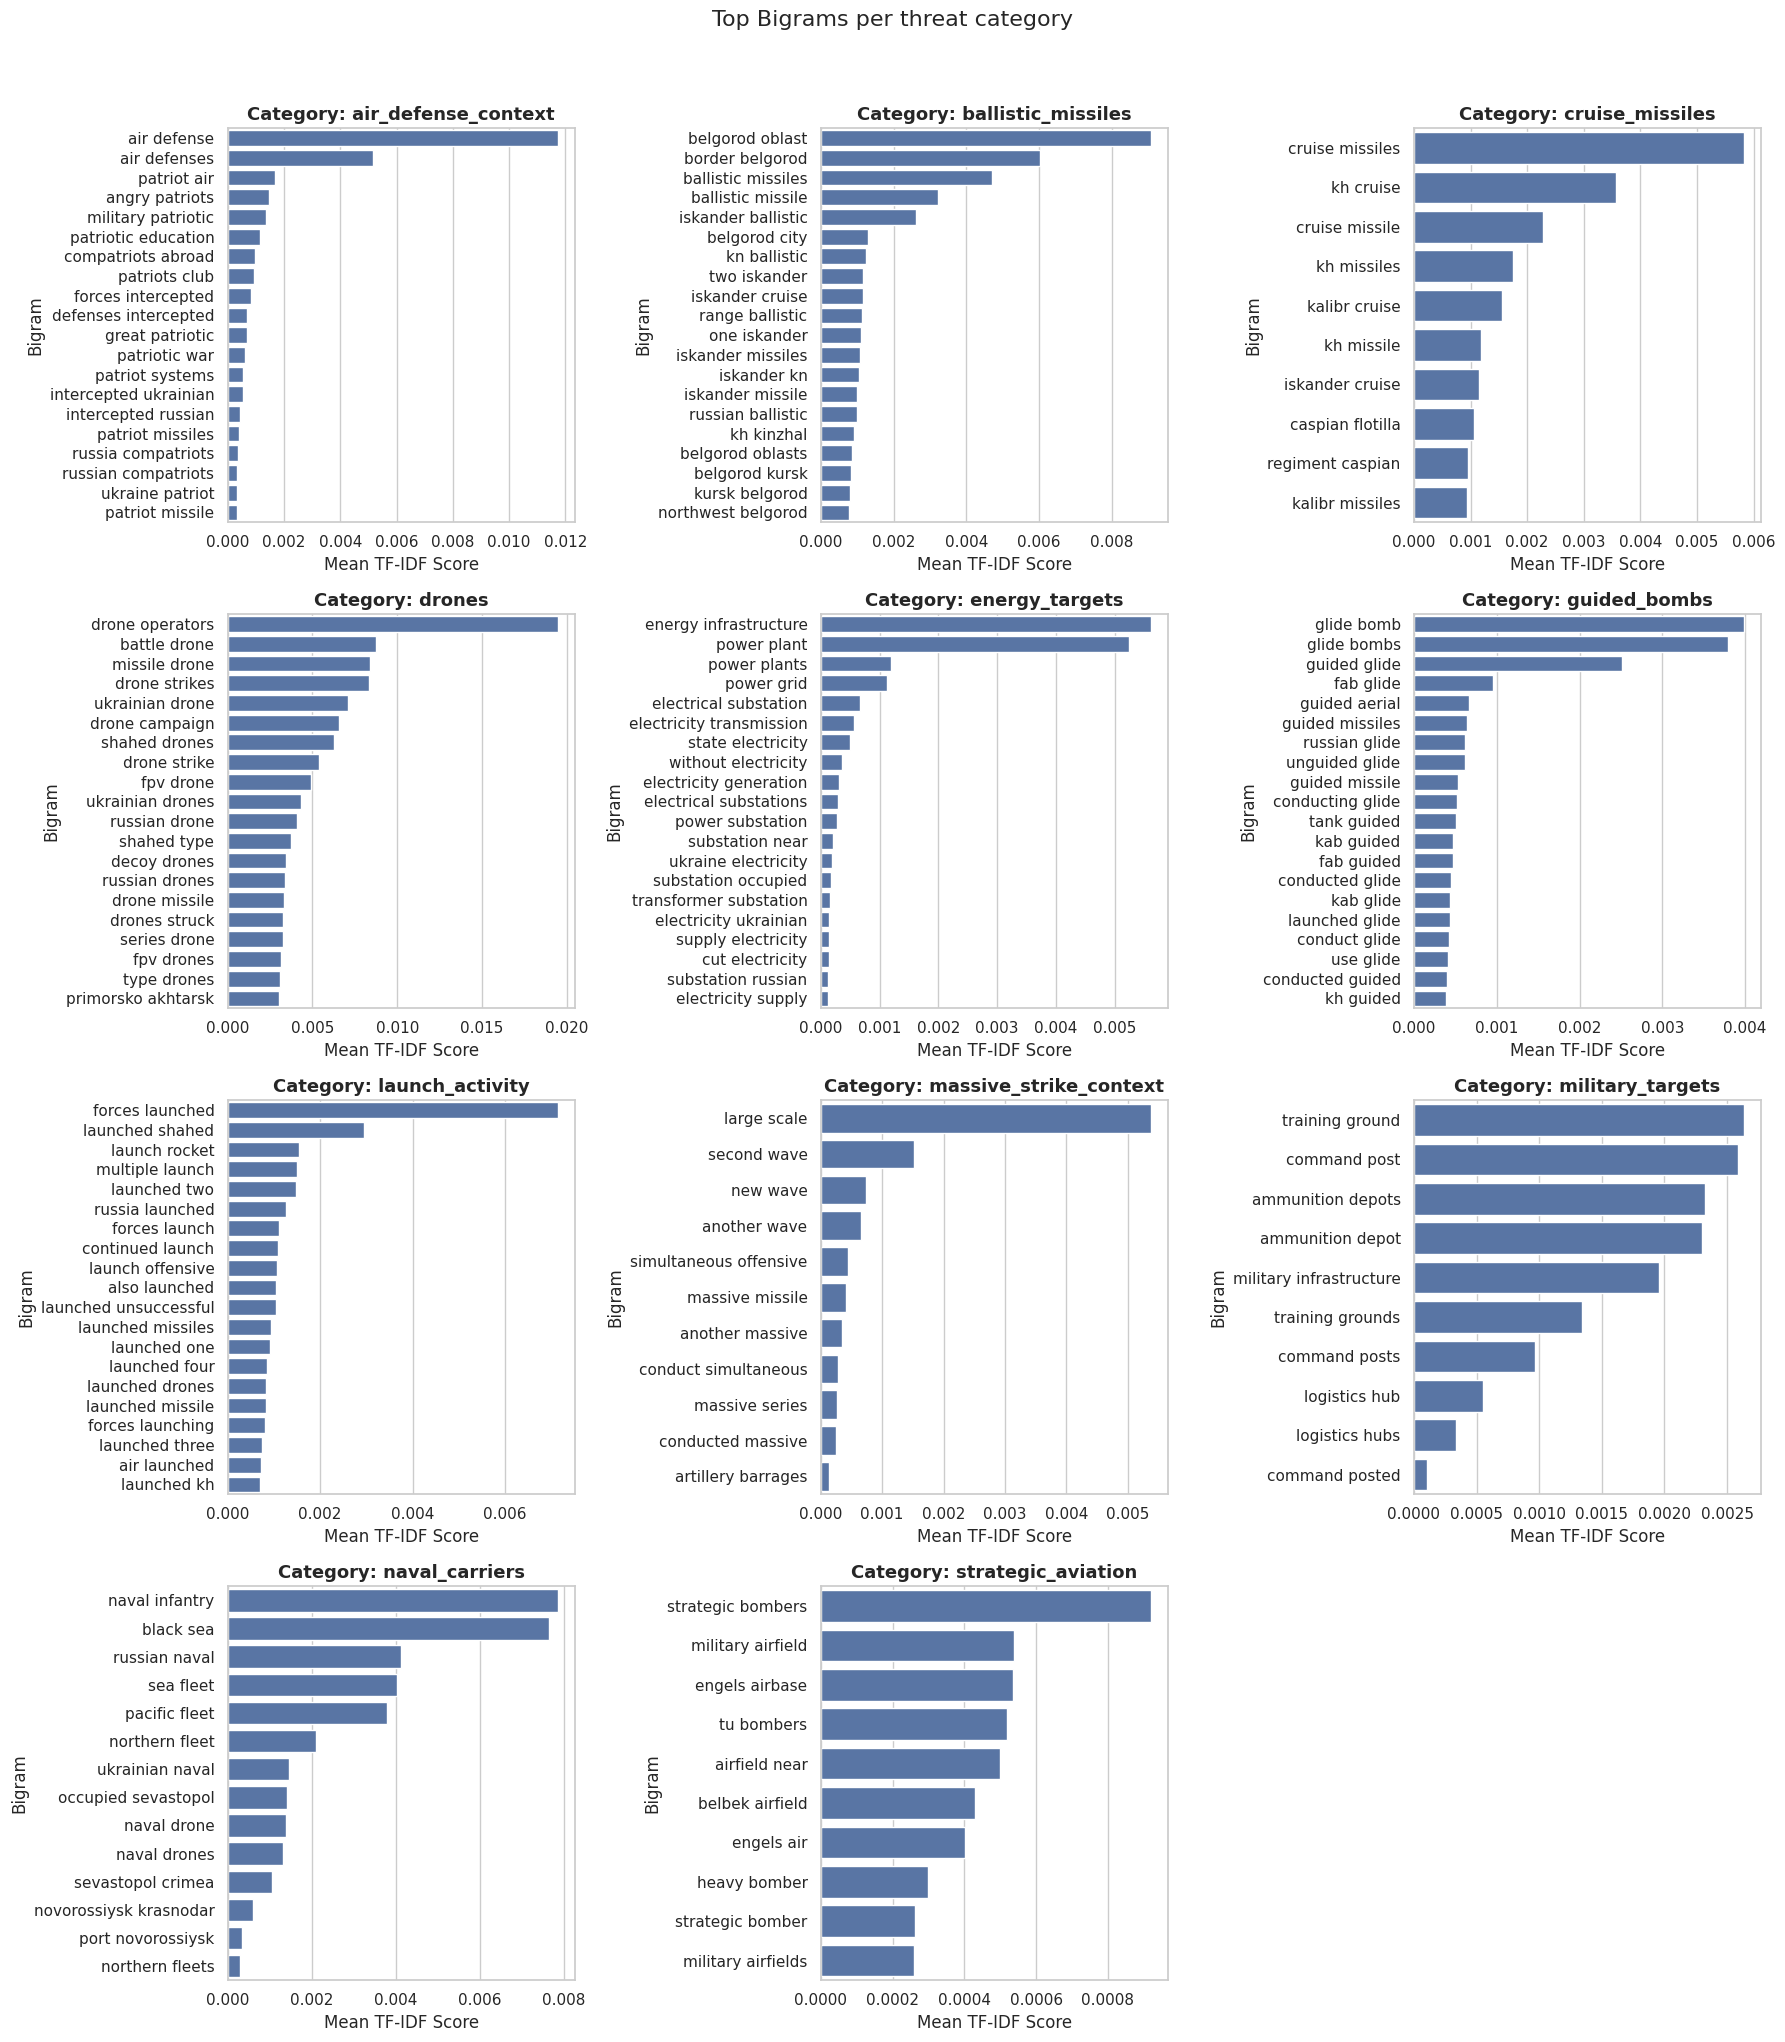

In [ ]:
categories = list(category_tables.keys())
n_cols = 3
n_rows = math.ceil(len(categories) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, category in enumerate(categories):
    df_cat = category_tables[category]
    sns.barplot(data=df_cat, x='score', y='bigram', ax=axes[i])
    axes[i].set_title(f'Category: {category}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Mean TF-IDF Score')
    axes[i].set_ylabel('Bigram')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Bigrams per threat category', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('isw_categories_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()

The visualization shows less relevant information for such categories: `air_defence_context, massive_strike_context`, we will not include those categories. For the last one we will apply another tool.

**4.1.4.2 Mean TF-IDF Score per category**

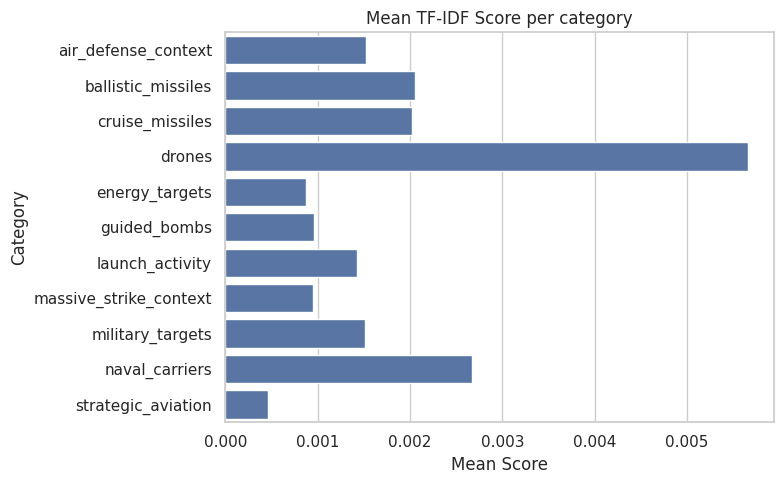

In [ ]:
coverage = {
    category: {'mean_score': df_cat['score'].mean()}
    for category, df_cat in category_tables.items()
}
coverage_df = pd.DataFrame(coverage).T.reset_index()
coverage_df.columns = ['category', 'mean_score']

plt.figure(figsize=(8, 5))
sns.barplot(data=coverage_df, x='mean_score', y='category')
plt.title('Mean TF-IDF Score per category')
plt.xlabel('Mean Score')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


Drones absolutely dominate: score is 2-3 times higher than the next category. This reflects reality: ISW writes about drones much more often and in more detail than about everything else. There is a risk that the model will simply learn to rely on drones and ignore the rest. Therefore, scaling will definitely be necessary to avoid dominance bias.

## 4.2 Geographic coverage

### 4.2.1 Defining regions

In [ ]:
# main regions
weather_cities_regex = {
    'Cherkasy': r'\b(?:cherkasy|cherkassy)\b',
    'Chernihiv': r'\b(?:chernihiv|chernigov)\b',
    'Chernivtsi': r'\b(?:chernivtsi|chernovtsy)\b',
    'Dnipro': r'\b(?:dnipro|dnipropetrovsk)\b',
    'Donetsk': r'\b(?:donetsk)\b',
    'Ivano-Frankivsk': r'\b(?:ivano-frankivsk|ivano frankivsk)\b',
    'Kharkiv': r'\b(?:kharkiv|kharkov)\b',
    'Kherson': r'\b(?:kherson)\b',
    'Khmelnytskyi': r'\b(?:khmelnytskyi|khmelnitsky)\b',
    'Kropyvnytskyi': r'\b(?:kropyvnytskyi|kirovohrad)\b',
    'Kyiv': r'\b(?:kyiv|kiev)\b',
    'Lutsk': r'\b(?:lutsk|volyn)\b',
    'Lviv': r'\b(?:lviv|lvov)\b',
    'Mykolaiv': r'\b(?:mykolaiv|nikolaev)\b',
    'Odesa': r'\b(?:odesa|odessa)\b',
    'Poltava': r'\b(?:poltava)\b',
    'Rivne': r'\b(?:rivne|rovno)\b',
    'Sumy': r'\b(?:sumy)\b',
    'Ternopil': r'\b(?:ternopil)\b',
    'Uzhhorod': r'\b(?:uzhhorod|uzhgorod|zakarpattia)\b',
    'Vinnytsia': r'\b(?:vinnytsia|vinnitsa)\b',
    'Zaporizhzhia': r'\b(?:zaporizhzhia|zaporizhia|zaporozhye)\b',
    'Zhytomyr': r'\b(?:zhytomyr|zhitomir)\b'
}

# other strategic cities
other_locations_regex = {
    'luhansk': r'\b(?:luhansk|lugansk)\b',
    'mariupol': r'\b(?:mariupol)\b',
    'bakhmut': r'\b(?:bakhmut|artemivsk)\b',
    'avdiivka': r'\b(?:avdiivka)\b',
    'sievierodonetsk': r'\b(?:sievierodonetsk|severodonetsk)\b',
    'lysychansk': r'\b(?:lysychansk)\b',
    'sloviansk': r'\b(?:sloviansk|slavyansk)\b',
    'kramatorsk': r'\b(?:kramatorsk)\b',
    'melitopol': r'\b(?:melitopol)\b',
    'berdiansk': r'\b(?:berdiansk)\b',
    'izium': r'\b(?:izium|izyum)\b',
    'kupiansk': r'\b(?:kupiansk)\b',
    'lyman': r'\b(?:lyman)\b',
    'vuhledar': r'\b(?:vuhledar)\b',
    'toretsk': r'\b(?:toretsk)\b',
    'pokrovsk': r'\b(?:pokrovsk)\b',
    'sevastopol': r'\b(?:sevastopol)\b',
    'simferopol': r'\b(?:simferopol)\b',
    'kerch': r'\b(?:kerch)\b'
}

ukraine_locations = {**weather_cities_regex, **other_locations_regex}

#city mentioned (one hot encoding)
for city, pattern in weather_cities_regex.items():
    col_name = f'isw_{city}'
    df_cleaned[col_name] = df_cleaned['cleaned_text'].str.contains(pattern, case=False, regex=True, na=False).astype(int)

#unique cities mantions score
def count_unique_locations(text):
    text = str(text)
    return sum(
        1 for pattern in ukraine_locations.values()
        if re.search(pattern, text, re.IGNORECASE)
    )

df_cleaned['geo_unique_locations'] = df_cleaned['cleaned_text'].apply(count_unique_locations).values

In [ ]:
df_cleaned.head(5)

,date,full_text,total_words,is_evening_report,report_timestamp,cleaned_text,isw_Cherkasy,isw_Chernihiv,isw_Chernivtsi,isw_Dnipro,...,isw_Odesa,isw_Poltava,isw_Rivne,isw_Sumy,isw_Ternopil,isw_Uzhhorod,isw_Vinnytsia,isw_Zaporizhzhia,isw_Zhytomyr,geo_unique_locations
0,2022-02-24,Previous\nNext\nRussia-Ukraine Warning Update:...,1593,0,2022-02-24 20:00:00,russian president vladimir putin began large s...,0,1,0,1,...,1,0,0,1,0,0,0,0,0,11
1,2022-02-25,Previous\nNext\nRussia-Ukraine Warning Update:...,1954,0,2022-02-25 20:00:00,russian forces entered major ukrainian cities ...,0,1,0,1,...,1,0,1,1,0,0,0,0,0,13
2,2022-02-26,Previous\nNext\nRussia-Ukraine Warning Update:...,2642,0,2022-02-26 20:00:00,russian forces main axes advance last hours fo...,0,1,0,1,...,1,0,1,0,0,0,0,0,0,11
3,2022-02-27,Previous\nNext\nRussia-Ukraine Warning Update:...,5111,0,2022-02-27 21:00:00,russian military likely recognized initial exp...,0,1,0,1,...,1,0,1,1,0,0,0,0,0,12
4,2022-02-28,Previous\nNext\nRussian Offensive Campaign Ass...,2489,0,2022-02-28 21:00:00,russian military reorganizing military efforts...,0,1,0,1,...,0,0,1,1,0,0,0,1,0,12



Geographic Coverage reflects the scale of military activity described in each ISW report. A higher number of unique locations mentioned in a single report indicates wider geographic spread of hostilities — which correlates with a higher probability of air alerts across multiple regions. This feature captures the breadth of daily conflict activity that threat-category features alone may miss.

### 4.2.2 Distribution cities per report

This histogram displays the frequency of various threat scales, showing how many reports mention a specific number of cities simultaneously, which enables the model to distinguish between typical events and large-scale anomalies.

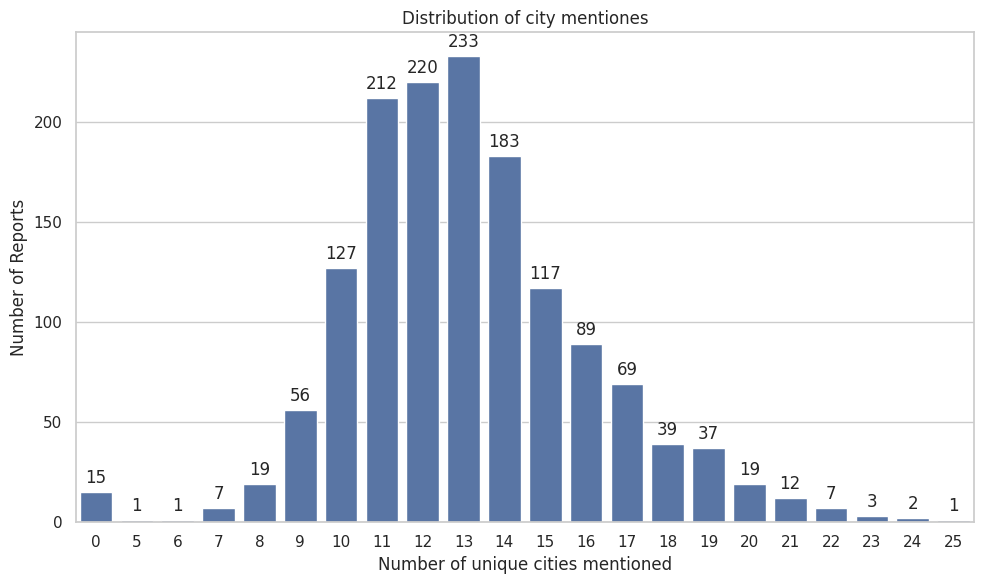

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_cleaned, x='geo_unique_locations')

plt.title('Distribution of city mentiones')
plt.xlabel('Number of unique cities mentioned')
plt.ylabel('Number of Reports')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

This line chart tracks the average number of unique locations per report over time, illustrating how the geographic scope of threats has evolved from localized incidents to more widespread, coordinated events.

### 4.2.3 Intensity of the top locarions per month

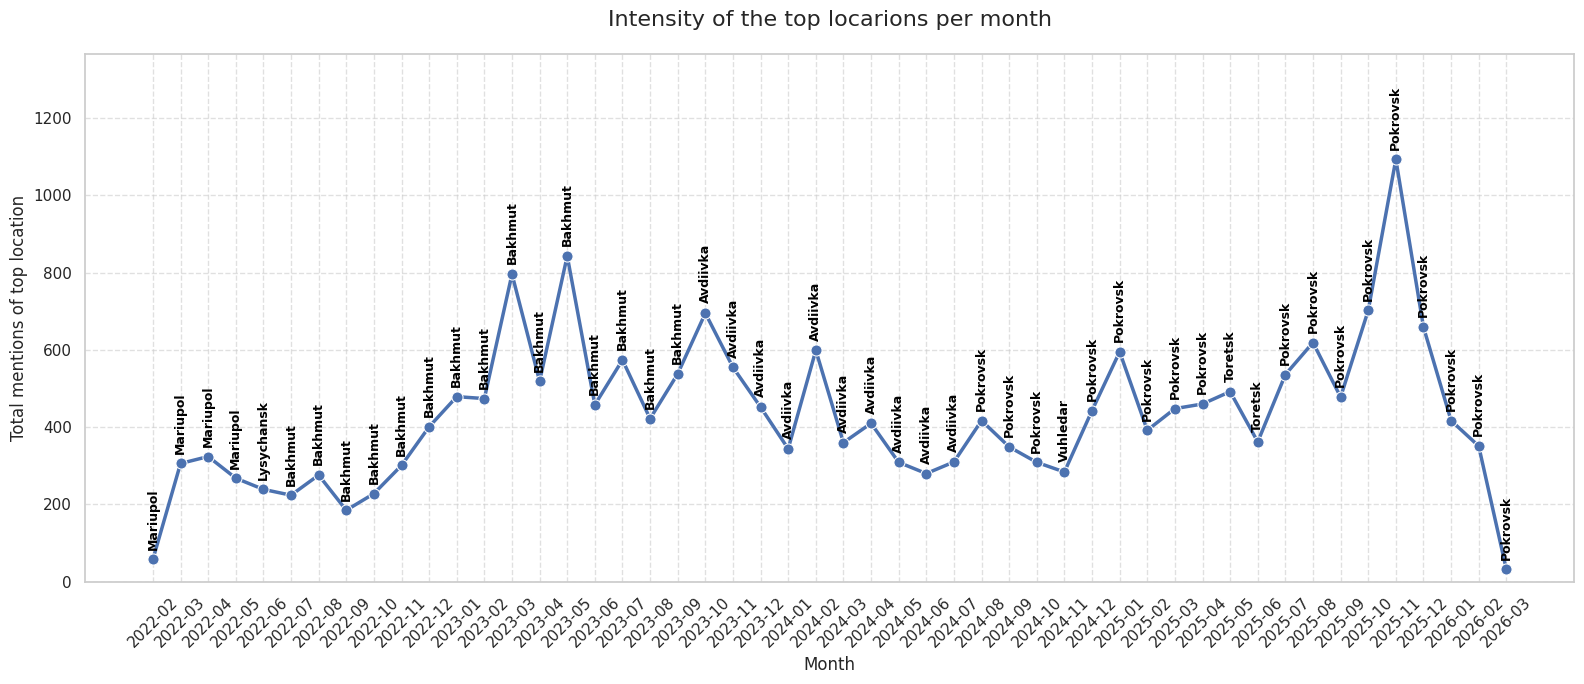

In [ ]:
df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
df_cleaned['year_month'] = df_cleaned['date'].dt.to_period('M')

def count_all_occurrences(text):
    text = str(text).lower()
    counts = {}
    for loc in ukraine_locations:
        c = text.count(loc)
        if c > 0:
            counts[loc] = c
    return counts

df_cleaned['all_city_frequencies'] = df_cleaned['cleaned_text'].apply(count_all_occurrences)

records = (
    df_cleaned[['year_month', 'all_city_frequencies']]
    .explode('all_city_frequencies')
)

df_exploded_all = (
    df_cleaned[['year_month', 'all_city_frequencies']]
    .apply(lambda row: pd.Series(row['all_city_frequencies']), axis=1)
    .fillna(0)
    .assign(year_month=df_cleaned['year_month'])
    .melt(id_vars='year_month', var_name='extracted_locations', value_name='mention_count')
    .query('mention_count > 0')
)

monthly_counts_all = df_exploded_all.groupby(['year_month', 'extracted_locations'])['mention_count'].sum().reset_index()

top_cities_all = monthly_counts_all.sort_values(by=['year_month', 'mention_count'], ascending=[True, False]).drop_duplicates('year_month')

top_cities_all['month_str'] = top_cities_all['year_month'].astype(str)
top_cities_all['extracted_locations'] = top_cities_all['extracted_locations'].str.capitalize()

plt.figure(figsize=(16, 7))

sns.lineplot(
    data=top_cities_all,
    x='month_str',
    y='mention_count',
    marker='o',
    linewidth=2.5,
    markersize=8
)

max_count = top_cities_all['mention_count'].max()

for index, row in enumerate(top_cities_all.itertuples()):
    plt.text(
        x=index,
        y=row.mention_count + (max_count * 0.03),
        s=row.extracted_locations,
        color='black',
        ha="center",
        rotation=90,
        fontsize=9,
        fontweight='bold'
    )

plt.title('Intensity of the top locarions per month', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total mentions of top location', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, max_count * 1.25)

plt.tight_layout()
plt.show()

This line chart identifies the single most mentioned city each month and tracks its mention frequency, highlighting the shifting geographical epicenter of intensity throughout the conflict.

## 4.3 Forming final dataset

### 4.3.1 Category scores per document and region coverage:

For each category we compute the mean TF-IDF value across matched bigrams.
Mean intensity is preferred over sum because it normalises for category size —
categories with more matched bigrams do not artificially dominate over smaller ones.

In [ ]:
isw_features_df = pd.DataFrame()
isw_features_df['date'] = df_cleaned.reset_index()['date']
isw_features_df['isw_report_timestamp'] = df_cleaned.reset_index()['report_timestamp']

# city mentioned score
isw_features_df['isw_geo_unique_locations'] = df_cleaned['cleaned_text'].apply(count_unique_locations).values

# bool type city columns
for city in weather_cities_regex.keys():
    col_name = f'isw_{city}'
    isw_features_df[col_name] = df_cleaned[col_name].values

# TF-IDF category features
exclude_categories = {'air_defense_context', 'massive_strike_context'}

for category, df_cat in category_tables.items():
    if category in exclude_categories:
        continue

    target_bigrams = [b for b in df_cat['bigram'].tolist() if b != '']
    existing_cols = [b for b in target_bigrams if b in df_tfidf.columns]

    isw_features_df[f'threat_{category}'] = df_tfidf[existing_cols].mean(axis=1).values

display(isw_features_df.head(10))

,date,isw_report_timestamp,isw_geo_unique_locations,isw_Cherkasy,isw_Chernihiv,isw_Chernivtsi,isw_Dnipro,isw_Donetsk,isw_Ivano-Frankivsk,isw_Kharkiv,...,isw_Zhytomyr,threat_ballistic_missiles,threat_cruise_missiles,threat_drones,threat_energy_targets,threat_guided_bombs,threat_launch_activity,threat_military_targets,threat_naval_carriers,threat_strategic_aviation
0,2022-02-24,2022-02-24 20:00:00,11,0,1,0,1,1,0,1,...,0,0.002321,0.001599,0.000000,0.000000,0.000000,0.001427,0.00000,0.001997,0.000000
1,2022-02-25,2022-02-25 20:00:00,13,0,1,0,1,1,0,1,...,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.003387,0.000000
2,2022-02-26,2022-02-26 20:00:00,11,0,1,0,1,1,0,1,...,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000371,0.00000,0.003800,0.000000
3,2022-02-27,2022-02-27 21:00:00,12,0,1,0,1,0,1,1,...,0,0.000000,0.000000,0.000495,0.000000,0.000000,0.000343,0.00000,0.004353,0.000000
4,2022-02-28,2022-02-28 21:00:00,12,0,1,0,1,1,0,1,...,0,0.001780,0.000000,0.000000,0.000605,0.005239,0.002235,0.00000,0.001146,0.000000
5,2022-03-01,2022-03-01 20:00:00,9,0,1,0,1,1,0,1,...,0,0.001302,0.000000,0.000000,0.000000,0.000000,0.003624,0.00212,0.000000,0.003172
6,2022-03-02,2022-03-02 22:00:00,10,0,1,0,1,1,0,1,...,1,0.000000,0.003031,0.000000,0.000000,0.000000,0.001219,0.00000,0.002315,0.000000
7,2022-03-03,2022-03-03 21:00:00,12,0,1,0,1,1,0,1,...,1,0.000000,0.003257,0.000000,0.000000,0.000000,0.001927,0.00000,0.003917,0.002708
8,2022-03-04,2022-03-04 20:00:00,12,0,1,0,1,1,0,1,...,0,0.000000,0.000000,0.000000,0.013389,0.000000,0.000000,0.00000,0.007806,0.000000
9,2022-03-05,2022-03-05 20:00:00,12,0,1,0,1,1,0,1,...,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.005622,0.000000


### 4.3.2 Lag and rolling features

ISW reports describe events that occurred before publication. Alarms may follow a report by 1-3 days. Lag features give the model explicit context about what was reported in previous days.

- `lag1`  — yesterday's report signal
- `lag3`  — signal from 3 days ago (covers delayed strike patterns)
- `roll7` — 7-day rolling mean (captures escalation trends)

In [ ]:
isw_features_df = isw_features_df.sort_values('date').reset_index(drop=True)

threat_cols = [col for col in isw_features_df.columns if col.startswith('threat_')]

for col in threat_cols:
    isw_features_df[f'{col}_lag1']  = isw_features_df[col].shift(1)
    isw_features_df[f'{col}_lag3']  = isw_features_df[col].shift(3)
    isw_features_df[f'{col}_roll7'] = isw_features_df[col].rolling(window=7, min_periods=1).mean()

# filling first days with nulls
lag_cols = [col for col in isw_features_df.columns if col.endswith('_lag1') or col.endswith('_lag3')]
isw_features_df[lag_cols] = isw_features_df[lag_cols].fillna(0)

Before using lag features in the model, we validate that they carry meaningful temporal signal. If past values of a threat category have no relationship with current values, the lag features would introduce noise rather than useful context. The scatter plots below confirm that the lag features are correctly shifted and correlated with the current day's signal.

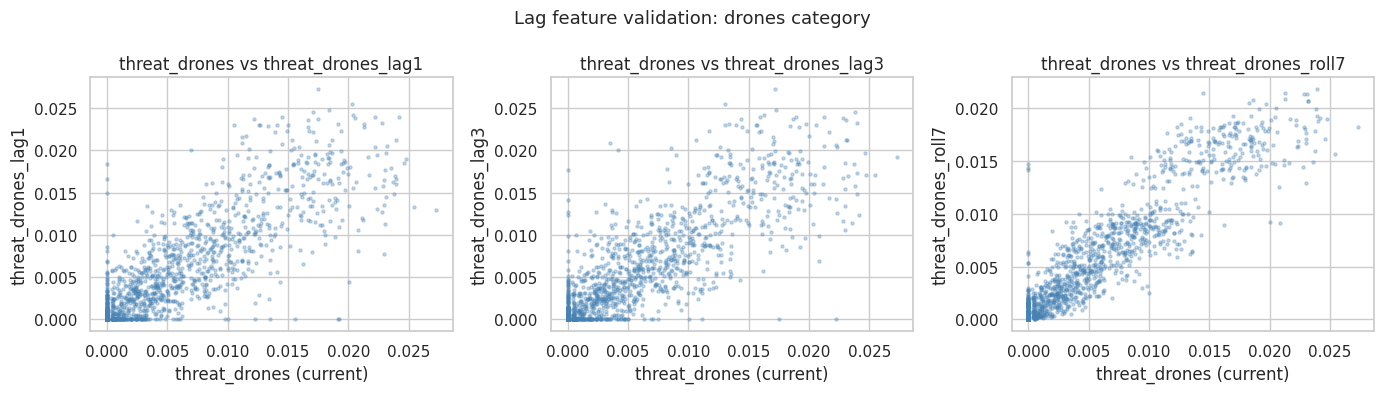

In [ ]:
lag_check_cols = ['threat_drones', 'threat_drones_lag1',
                  'threat_drones_lag3', 'threat_drones_roll7']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, lag_col in enumerate(['threat_drones_lag1',
                              'threat_drones_lag3',
                              'threat_drones_roll7']):
    axes[i].scatter(isw_features_df['threat_drones'],
                    isw_features_df[lag_col], alpha=0.3, s=5, color='steelblue')
    axes[i].set_xlabel('threat_drones (current)')
    axes[i].set_ylabel(lag_col)
    axes[i].set_title(f'threat_drones vs {lag_col}')

plt.suptitle('Lag feature validation: drones category', fontsize=13)
plt.tight_layout()
plt.show()

All three plots show a positive correlation, confirming that historical drone threat intensity is predictive of current values. The roll7 feature shows the tightest relationship because it averages out daily noise across 7 days — smoothing random spikes and capturing the underlying trend rather than a single day's fluctuation. lag1 shows a strong but noisier relationship, while lag3 is weaker, reflecting that signal degrades over time. This confirms all three lag features carry valid and distinct temporal information for the model.

The table below lists all features produced by this notebook, grouped by type.

**Temporal features (2)**
- `isw_report_timestamp` — exact UTC publication time of the report,
  rounded up to the nearest hour
- `is_evening_report` — binary flag: 1 = published after 18:00 ET, 0 = earlier

**Geographic features (24)**
- `isw_geo_unique_locations` — count of unique Ukrainian regions mentioned
  in the report on that day
- `isw_{City}` — binary indicator (0/1) for each of the 23 oblast centers,
  reflecting whether the region was mentioned in the report on that day

**Threat category features (9 categories × 4 = 36)**
For each of the 9 threat categories — drones, ballistic_missiles,
cruise_missiles, guided_bombs, strategic_aviation, naval_carriers,
launch_activity, energy_targets, military_targets:
- `threat_{category}` — mean TF-IDF intensity of matched bigrams for that day
- `threat_{category}_lag1` — value from the previous day
- `threat_{category}_lag3` — value from 3 days ago
- `threat_{category}_roll7` — 7-day rolling mean (captures escalation trends)

**Total: 62 features across 1,469 daily records
(February 24, 2022 — March 2026)**

## 4.4 Feature Engineering Summary

### 4.4.1 Final dataset

In [ ]:
print(f"Final isw_features_df shape: {isw_features_df.shape}")
print(f"NaN remaining: {isw_features_df.isna().sum().sum()}")

display(isw_features_df.head(10))

isw_features_df.info()

Final isw_features_df shape: (1469, 62)
NaN remaining: 0


,date,isw_report_timestamp,isw_geo_unique_locations,isw_Cherkasy,isw_Chernihiv,isw_Chernivtsi,isw_Dnipro,isw_Donetsk,isw_Ivano-Frankivsk,isw_Kharkiv,...,threat_launch_activity_roll7,threat_military_targets_lag1,threat_military_targets_lag3,threat_military_targets_roll7,threat_naval_carriers_lag1,threat_naval_carriers_lag3,threat_naval_carriers_roll7,threat_strategic_aviation_lag1,threat_strategic_aviation_lag3,threat_strategic_aviation_roll7
0,2022-02-24,2022-02-24 20:00:00,11,0,1,0,1,1,0,1,...,0.001427,0.00000,0.00000,0.000000,0.000000,0.000000,0.001997,0.000000,0.000000,0.000000
1,2022-02-25,2022-02-25 20:00:00,13,0,1,0,1,1,0,1,...,0.000714,0.00000,0.00000,0.000000,0.001997,0.000000,0.002692,0.000000,0.000000,0.000000
2,2022-02-26,2022-02-26 20:00:00,11,0,1,0,1,1,0,1,...,0.000599,0.00000,0.00000,0.000000,0.003387,0.000000,0.003061,0.000000,0.000000,0.000000
3,2022-02-27,2022-02-27 21:00:00,12,0,1,0,1,0,1,1,...,0.000535,0.00000,0.00000,0.000000,0.003800,0.001997,0.003384,0.000000,0.000000,0.000000
4,2022-02-28,2022-02-28 21:00:00,12,0,1,0,1,1,0,1,...,0.000875,0.00000,0.00000,0.000000,0.004353,0.003387,0.002937,0.000000,0.000000,0.000000
5,2022-03-01,2022-03-01 20:00:00,9,0,1,0,1,1,0,1,...,0.001333,0.00000,0.00000,0.000353,0.001146,0.003800,0.002447,0.000000,0.000000,0.000529
6,2022-03-02,2022-03-02 22:00:00,10,0,1,0,1,1,0,1,...,0.001317,0.00212,0.00000,0.000303,0.000000,0.004353,0.002428,0.003172,0.000000,0.000453
7,2022-03-03,2022-03-03 21:00:00,12,0,1,0,1,1,0,1,...,0.001388,0.00000,0.00000,0.000303,0.002315,0.001146,0.002703,0.000000,0.000000,0.000840
8,2022-03-04,2022-03-04 20:00:00,12,0,1,0,1,1,0,1,...,0.001388,0.00000,0.00212,0.000303,0.003917,0.000000,0.003334,0.002708,0.003172,0.000840
9,2022-03-05,2022-03-05 20:00:00,12,0,1,0,1,1,0,1,...,0.001335,0.00000,0.00000,0.000303,0.007806,0.002315,0.003594,0.000000,0.000000,0.000840


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469 entries, 0 to 1468
Data columns (total 62 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   date                             1469 non-null   datetime64[ns]
 1   isw_report_timestamp             1469 non-null   object        
 2   isw_geo_unique_locations         1469 non-null   int64         
 3   isw_Cherkasy                     1469 non-null   int64         
 4   isw_Chernihiv                    1469 non-null   int64         
 5   isw_Chernivtsi                   1469 non-null   int64         
 6   isw_Dnipro                       1469 non-null   int64         
 7   isw_Donetsk                      1469 non-null   int64         
 8   isw_Ivano-Frankivsk              1469 non-null   int64         
 9   isw_Kharkiv                      1469 non-null   int64         
 10  isw_Kherson                      1469 non-null   int64      

In [ ]:
isw_features_df.to_csv('isw_reports.csv', index=False)

The final dataset covers the full period of Russia's large-scale invasion from
February 24, 2022 to present. Each row represents one day and contains signals
extracted from the ISW conflict assessment report published that day — or, for
the 15 days with no report, neutral zero-filled values.

The dataset is intentionally not scaled at this stage. MinMaxScaler will be
applied after merging with the weather and air alert datasets to prevent data
leakage between sources and ensure consistent scaling across all feature groups
before model training.

# 5. Pipeline Summary



This notebook transformed raw ISW daily conflict assessment reports into a
structured numerical feature dataset for air alert prediction in Ukraine.

**Section 2: Data Overview**

Basic exploration of the raw dataset:
- structure validation,
- time period coverage,
- missing dates identification,
- duplicate detection,
- word count anomaly analysis

**Section 3: Preprocessing & Cleaning**
- Removal of consolidated multi-month report outlier
- Deduplication by merging same-day reports into single records
- Timestamp extraction and engineering of `is_evening_report` binary feature
- Publication time conversion from ET to UTC with timezone-aware rounding
- ISW-specific header and footer removal (navigation links, author lines, footnotes)
- Text normalization: URL removal, digit stripping, lowercasing, stopword filtering
- Missing date imputation: 15 days filled with empty text and neutral feature values

**Section 4: Feature Engineering**
- TF-IDF vectorization using bigrams (min_df=5, max_df=0.98)
- Keyword-based threat category extraction across 9 categories:
  drones, ballistic missiles, cruise missiles, guided bombs, strategic aviation,
  naval carriers, launch activity, energy targets, military targets
- Two-stage categorization: initial keyword matching → corpus diagnostics →
  expanded bigram vocabulary based on actual corpus content
- Geographic coverage features: per-region binary indicators (23 Ukrainian regions)
  and total unique location count per report
- Temporal features: lag-1, lag-3, and 7-day rolling mean for all threat categories

## Output
`isw_features_data.csv` — 1,469 rows × 62 columns, one row per day from
February 24, 2022, with no missing values. Ready for merge with weather
and air alert datasets before model training.